In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

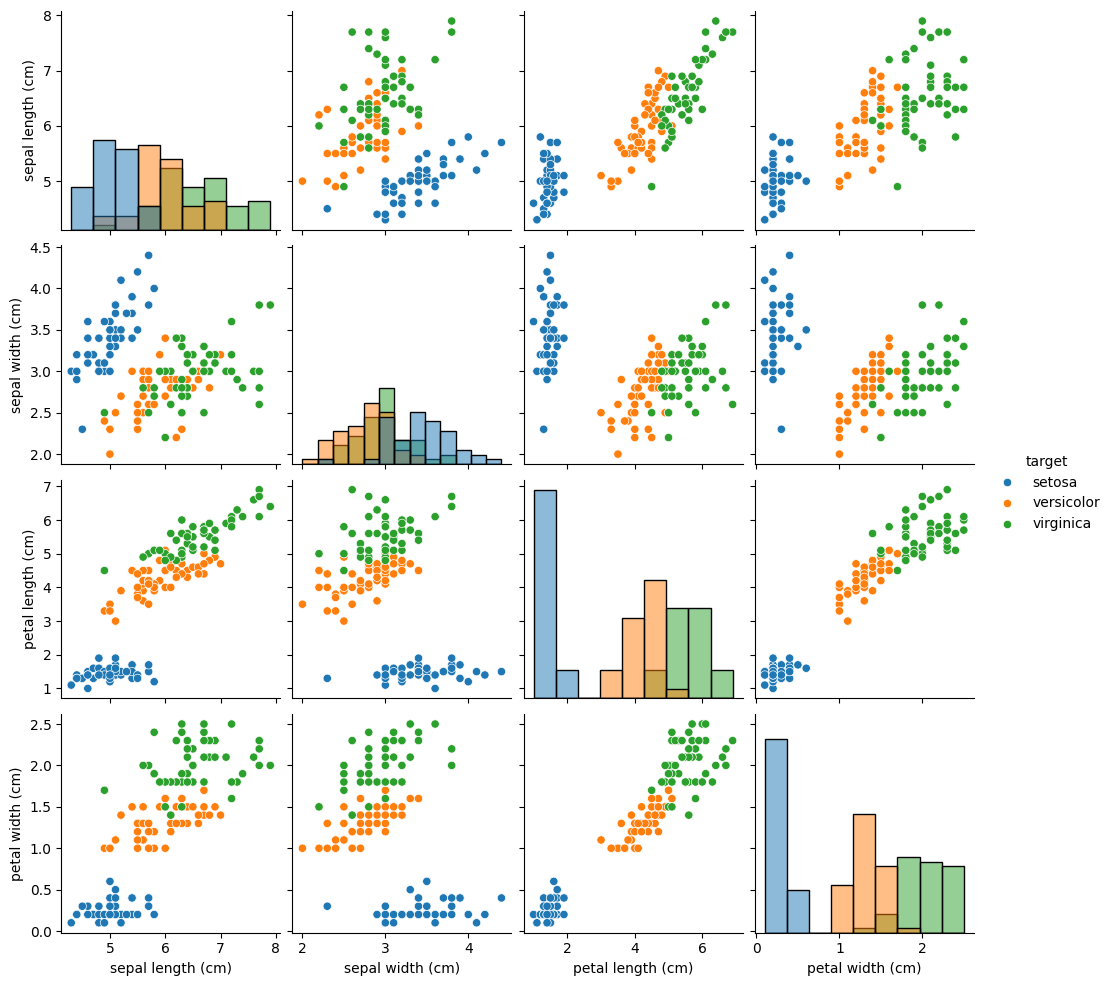

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


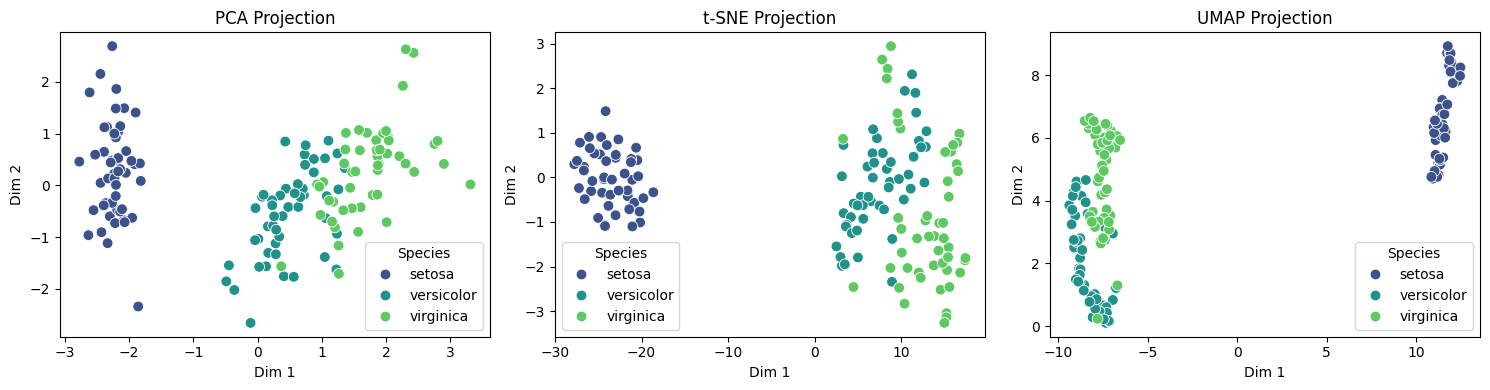

In [20]:
from sklearn.datasets import load_iris

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['target'] = iris_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

sns.pairplot(iris_df, hue='target', diag_kind='hist')
plt.show()

# --- DIMENSIONALITY REDUCTION ON IRIS ---
X_scaled = StandardScaler().fit_transform(iris.data)
labels = iris_df['target'].values

# PCA
pca_res = PCA(n_components=2).fit_transform(X_scaled)

# t-SNE
tsne_res = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)

# UMAP
umap_res = umap.UMAP(n_components=2, n_neighbors=15, random_state=42).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
results = [('PCA', pca_res), ('t-SNE', tsne_res), ('UMAP', umap_res)]
for ax, (title, res_data) in zip(axes, results):
    plot_df = pd.DataFrame(res_data, columns=['Dim 1', 'Dim 2'])
    plot_df['Species'] = labels
    sns.scatterplot(data=plot_df, x='Dim 1', y='Dim 2', hue='Species', ax=ax, s=60, palette='viridis')
    ax.set_title(f"{title} Projection")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


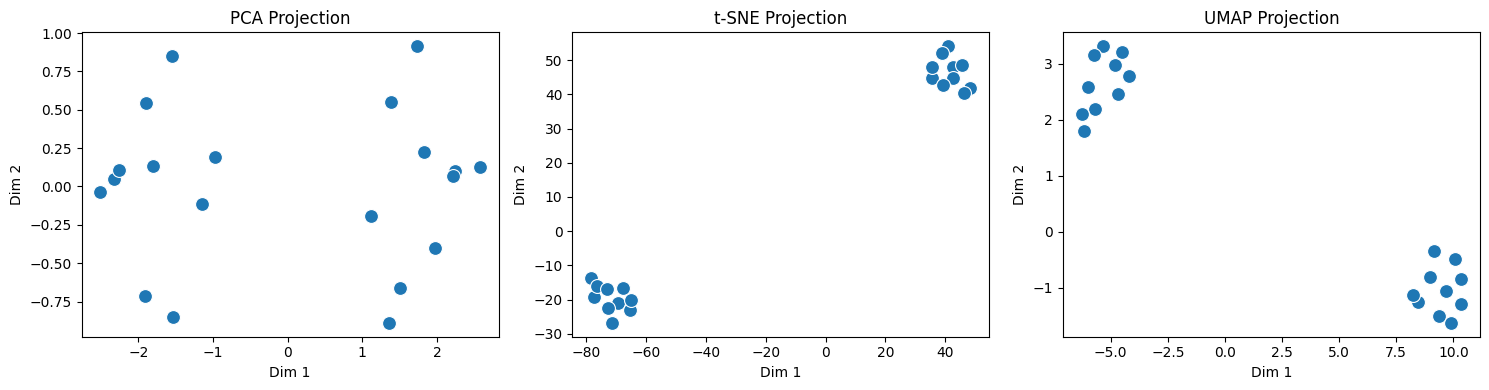

In [25]:
# --- DATASET GENERATION (Do not change) ---
np.random.seed(42)
data = np.random.randn(20, 4)
data[10:, :] += 3.5 # Create 2 groups
labels = ['Group A']*10 + ['Group B']*10
df = pd.DataFrame(data, columns=['F1', 'F2', 'F3', 'F4'])

X_scaled = StandardScaler().fit_transform(df.values)      # Standardize data
# PCA
pca_res = PCA(n_components=2).fit_transform(X_scaled)
tsne_res = TSNE(n_components=2, perplexity=5, random_state=42).fit_transform(X_scaled)   #perplexity should be less than sample size
# UMAP
umap_res = umap.UMAP(n_components=2, n_neighbors=5, random_state=42).fit_transform(X_scaled)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
results = [('PCA', pca_res), ('t-SNE', tsne_res), ('UMAP', umap_res)]
for ax, (title, res_data) in zip(axes, results):
    plot_df = pd.DataFrame(res_data, columns=['Dim 1', 'Dim 2'])
    sns.scatterplot(data=plot_df, x='Dim 1', y='Dim 2', ax=ax, s=100)     #LINE: not valid syntax
    ax.set_title(f"{title} Projection")
plt.tight_layout()
plt.show()